# Zee Movie Recommender System
### Collaborative Filtering: Pearson Correlation | Cosine Similarity / KNN | Matrix Factorization

Building a personalized movie recommendation engine using the Movie dataset
(`movies.dat`, `ratings.dat`, `users.dat`). Following an **item-based** and **user-based**
collaborative filtering approach, plus **matrix factorization** with latent embeddings.


## 1. Setup & Data Loading

In [ ]:
!pip install scikit-surprise -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.3 MB/s eta 0:00:00


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)


### 1.1 Upload the data files


In [ ]:

movies = pd.read_csv('/content/zee-movies.dat', sep='::', engine='python', encoding='ISO-8859-1')



users = pd.read_csv('/content/zee-users.dat', sep='::', engine='python', encoding='ISO-8859-1')



ratings = pd.read_csv('/content/zee-ratings.dat', sep='::', engine='python', encoding='ISO-8859-1')


print("movies :", movies.shape)
print("users  :", users.shape)
print("ratings:", ratings.shape)

movies.head()


movies : (3883, 3)
users  : (6040, 5)
ratings: (1000209, 4)


,Movie ID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
users.head()

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [ ]:
ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


## 2. Merging the Data Files into a Single DataFrame

In [ ]:
# Rename 'Movie ID' to 'MovieID' in the movies dataframe to match ratings
movies = movies.rename(columns={'Movie ID': 'MovieID'})

# merging users and movies
df = ratings.merge(users, on='UserID', how='left').merge(movies, on='MovieID', how='left')

print(df.shape)
df.head()


(1000209, 10)


,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Title,Genres
0,1,1193,5,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,F,1,10,48067,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   UserID      1000209 non-null  int64 
 1   MovieID     1000209 non-null  int64 
 2   Rating      1000209 non-null  int64 
 3   Timestamp   1000209 non-null  int64 
 4   Gender      1000209 non-null  object
 5   Age         1000209 non-null  int64 
 6   Occupation  1000209 non-null  int64 
 7   Zip-code    1000209 non-null  object
 8   Title       1000209 non-null  object
 9   Genres      1000209 non-null  object
dtypes: int64(6), object(4)
memory usage: 76.3+ MB


## 3. EDA, Data Cleaning & Feature Engineering

We check the shape & structure of the data, look for missing values / duplicates, convert types,
and derive new features: `Rating_Date`, `Release_Year`, `Decade`, `Age_Group`, `Occupation_Desc`,
and a one-hot `Genres` breakdown.

In [ ]:

print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUserID range:", df.UserID.min(), "-", df.UserID.max())
print("MovieID range:", df.MovieID.min(), "-", df.MovieID.max())
print("Rating values:", sorted(df.Rating.unique()))


Missing values:
 UserID        0
MovieID       0
Rating        0
Timestamp     0
Gender        0
Age           0
Occupation    0
Zip-code      0
Title         0
Genres        0
dtype: int64

Duplicate rows: 0

UserID range: 1 - 6040
MovieID range: 1 - 3952
Rating values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [ ]:

#  Timestamp -> datetime (seconds since epoch)
df['Rating_Date'] = pd.to_datetime(df['Timestamp'], unit='s')
df['Rating_Year'] = df['Rating_Date'].dt.year

#  Extract Release Year from the Title, e.g. "Toy Story (1995)" -> 1995
df['Release_Year'] = df['Title'].str.extract(r'\((\d{4})\)$').astype('float').astype('Int64')
df['Title_clean'] = df['Title'].str.replace(r'\s*\(\d{4}\)$', '', regex=True)

df['Decade'] = (df['Release_Year'] // 10 * 10).astype('Int64').astype(str) + 's'

#  Map Age codes & Occupation codes to human-readable labels
age_map = {1: 'Under 18', 18: '18-24', 25: '25-34', 35: '35-44',
           45: '45-49', 50: '50-55', 56: '56+'}
occ_map = {
    0: 'other/not specified', 1: 'academic/educator', 2: 'artist', 3: 'clerical/admin',
    4: 'college/grad student', 5: 'customer service', 6: 'doctor/health care',
    7: 'executive/managerial', 8: 'farmer', 9: 'homemaker', 10: 'K-12 student',
    11: 'lawyer', 12: 'programmer', 13: 'retired', 14: 'sales/marketing',
    15: 'scientist', 16: 'self-employed', 17: 'technician/engineer',
    18: 'tradesman/craftsman', 19: 'unemployed', 20: 'writer'
}
df['Age_Group'] = df['Age'].map(age_map)
df['Occupation_Desc'] = df['Occupation'].map(occ_map)

#  Genres as a list + one-hot columns (useful for later genre-level analysis)
df['Genres_list'] = df['Genres'].str.split('|')
genre_dummies = df['Genres'].str.get_dummies(sep='|')
print("Distinct genres:", list(genre_dummies.columns))

df.head()


Distinct genres: ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Title,Genres,Rating_Date,Rating_Year,Release_Year,Title_clean,Decade,Age_Group,Occupation_Desc,Genres_list
0,1,1193,5,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama,2000-12-31 22:12:40,2000,1975,One Flew Over the Cuckoo's Nest,1970s,Under 18,K-12 student,[Drama]
1,1,661,3,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical,2000-12-31 22:35:09,2000,1996,James and the Giant Peach,1990s,Under 18,K-12 student,"[Animation, Children's, Musical]"
2,1,914,3,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance,2000-12-31 22:32:48,2000,1964,My Fair Lady,1960s,Under 18,K-12 student,"[Musical, Romance]"
3,1,3408,4,978300275,F,1,10,48067,Erin Brockovich (2000),Drama,2000-12-31 22:04:35,2000,2000,Erin Brockovich,2000s,Under 18,K-12 student,[Drama]
4,1,2355,5,978824291,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy,2001-01-06 23:38:11,2001,1998,"Bug's Life, A",1990s,Under 18,K-12 student,"[Animation, Children's, Comedy]"


In [ ]:

# Sanity checks on the engineered features
print("Any null Release_Year?", df['Release_Year'].isnull().sum())
print("Release year range:", df['Release_Year'].min(), "-", df['Release_Year'].max())
print("\nRatings per user  -> min: {}, max: {}, mean: {:.1f}".format(
    df.groupby('UserID').size().min(), df.groupby('UserID').size().max(),
    df.groupby('UserID').size().mean()))
print("Ratings per movie -> min: {}, max: {}, mean: {:.1f}".format(
    df.groupby('MovieID').size().min(), df.groupby('MovieID').size().max(),
    df.groupby('MovieID').size().mean()))


Any null Release_Year? 0
Release year range: 1919 - 2000

Ratings per user  -> min: 20, max: 2314, mean: 165.6
Ratings per movie -> min: 1, max: 3428, mean: 269.9


### 3.1 Visualizations

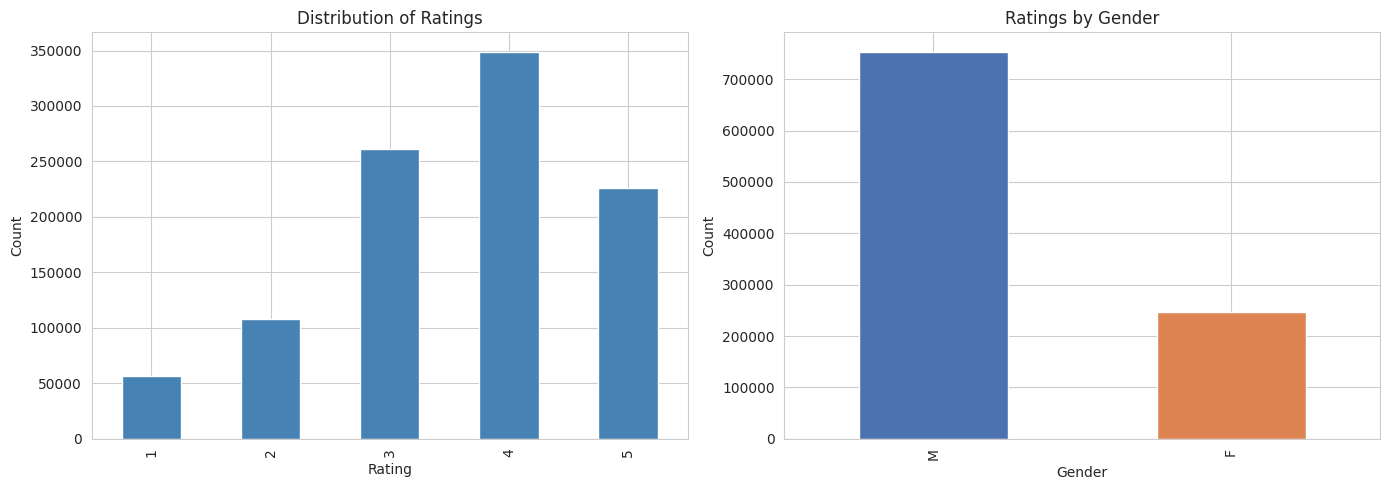

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['Rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Ratings')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')

df['Gender'].value_counts().plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Ratings by Gender')
axes[1].set_xlabel('Gender'); axes[1].set_ylabel('Count')
plt.tight_layout(); plt.show()


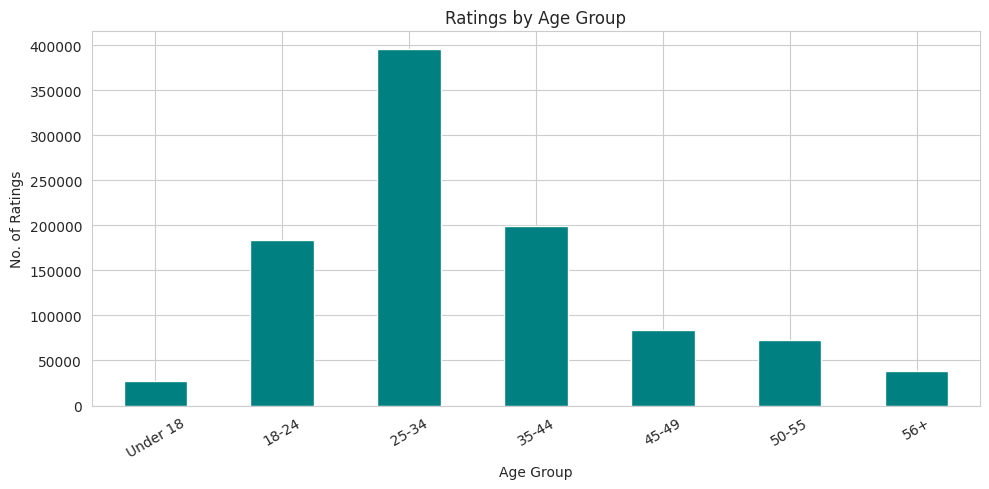

In [ ]:

order = ['Under 18', '18-24', '25-34', '35-44', '45-49', '50-55', '56+']
plt.figure(figsize=(10, 5))
df['Age_Group'].value_counts().reindex(order).plot(kind='bar', color='teal')
plt.title('Ratings by Age Group'); plt.xlabel('Age Group'); plt.ylabel('No. of Ratings')
plt.xticks(rotation=30); plt.tight_layout(); plt.show()


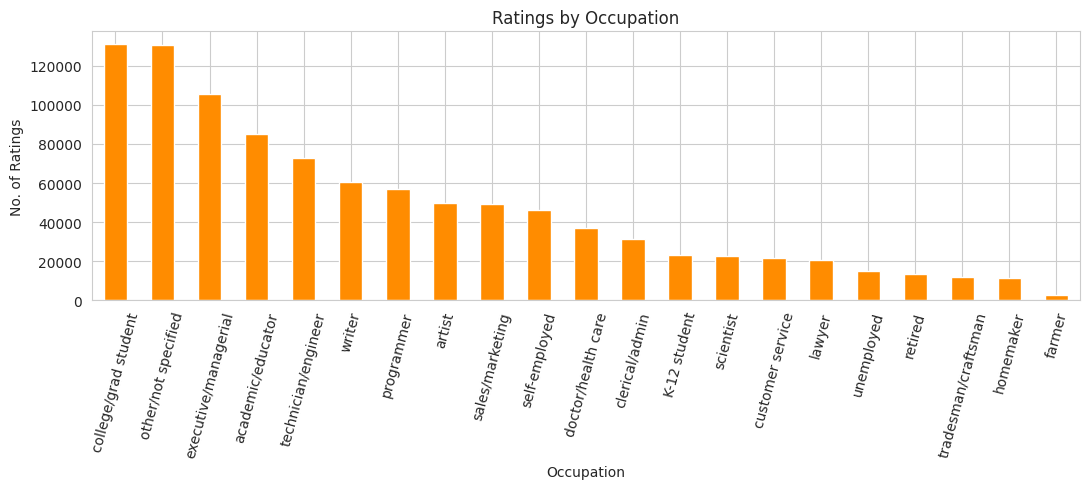

In [ ]:

plt.figure(figsize=(11, 5))
df['Occupation_Desc'].value_counts().plot(kind='bar', color='darkorange')
plt.title('Ratings by Occupation'); plt.xlabel('Occupation'); plt.ylabel('No. of Ratings')
plt.xticks(rotation=75); plt.tight_layout(); plt.show()


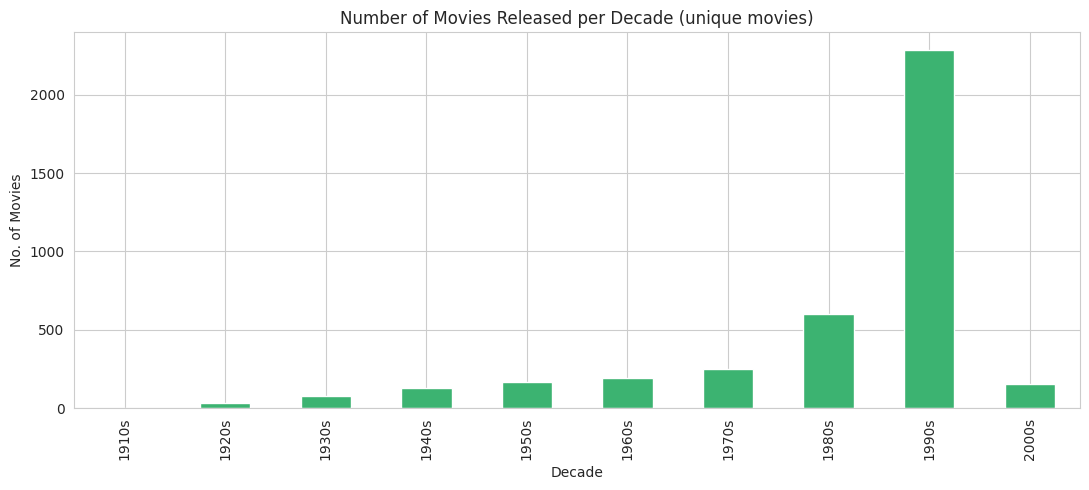

In [ ]:

decade_counts = movies.assign(
    Release_Year=movies['Title'].str.extract(r'\((\d{4})\)$').astype(float)
)
decade_counts['Decade'] = (decade_counts['Release_Year'] // 10 * 10).astype('Int64').astype(str) + 's'

plt.figure(figsize=(11, 5))
decade_counts['Decade'].value_counts().sort_index().plot(kind='bar', color='mediumseagreen')
plt.title('Number of Movies Released per Decade (unique movies)')
plt.xlabel('Decade'); plt.ylabel('No. of Movies')
plt.tight_layout(); plt.show()


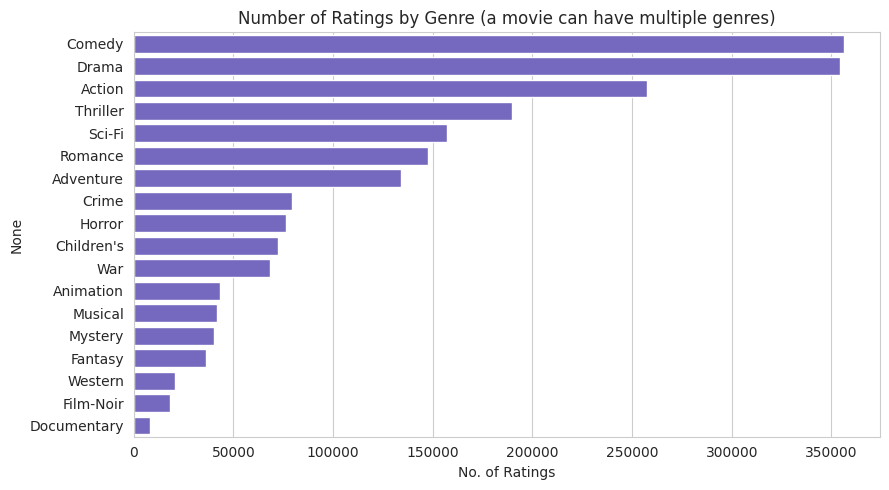

In [ ]:

plt.figure(figsize=(9, 5))
genre_counts = genre_dummies.sum().sort_values(ascending=False)
sns.barplot(x=genre_counts.values, y=genre_counts.index, color='slateblue')
plt.title('Number of Ratings by Genre (a movie can have multiple genres)')
plt.xlabel('No. of Ratings'); plt.tight_layout(); plt.show()


## 4. Grouping by Average Rating & Number of Ratings

We compute, per movie, the mean rating and the count of ratings. This is also useful later to
filter out movies with too few ratings before running similarity computations (a movie rated by
1-2 people produces unreliable/noisy correlations).

In [ ]:

movie_stats = df.groupby('Title').agg(
    Avg_Rating=('Rating', 'mean'),
    No_of_Ratings=('Rating', 'count')
).reset_index().sort_values('No_of_Ratings', ascending=False)

movie_stats.head(10)


,Title,Avg_Rating,No_of_Ratings
127,American Beauty (1999),4.317386,3428
3153,Star Wars: Episode IV - A New Hope (1977),4.453694,2991
3154,Star Wars: Episode V - The Empire Strikes Back...,4.292977,2990
3155,Star Wars: Episode VI - Return of the Jedi (1983),4.022893,2883
1789,Jurassic Park (1993),3.763847,2672
2894,Saving Private Ryan (1998),4.337354,2653
3293,Terminator 2: Judgment Day (1991),4.058513,2649
2112,"Matrix, The (1999)",4.315830,2590
258,Back to the Future (1985),3.990321,2583
2990,"Silence of the Lambs, The (1991)",4.351823,2578


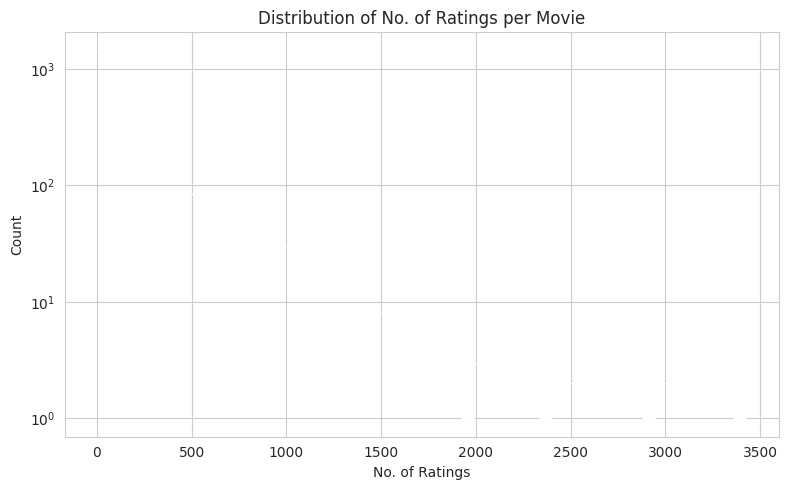

Top 10 highest-rated movies (>= 100 ratings):


,Title,Avg_Rating,No_of_Ratings
2940,Seven Samurai (The Magnificent Seven) (Shichin...,4.560510,628
2970,"Shawshank Redemption, The (1994)",4.554558,2227
1354,"Godfather, The (1972)",4.524966,2223
713,"Close Shave, A (1995)",4.520548,657
3504,"Usual Suspects, The (1995)",4.517106,1783
2901,Schindler's List (1993),4.510417,2304
3675,"Wrong Trousers, The (1993)",4.507937,882
3218,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.491489,470
2711,Raiders of the Lost Ark (1981),4.477725,2514
2738,Rear Window (1954),4.476190,1050


In [ ]:

plt.figure(figsize=(8, 5))
sns.histplot(movie_stats['No_of_Ratings'], bins=50, log_scale=(False, True), color='crimson')
plt.title('Distribution of No. of Ratings per Movie')
plt.xlabel('No. of Ratings'); plt.tight_layout(); plt.show()

print("Top 10 highest-rated movies (>= 100 ratings):")
movie_stats[movie_stats['No_of_Ratings'] >= 100].sort_values('Avg_Rating', ascending=False).head(10)


## 5. Pivot Table: Movie Titles × User IDs

We build the classic **user-item ratings matrix**. To keep the matrix computationally
manageable and the similarity scores statistically meaningful, we first restrict to movies with
at least **30 ratings** and users with at least **30 ratings** (a very common, well-documented
practice for this exact dataset). We keep two versions:

- `pivot_nan`  with `NaN` for missing ratings, used for **Pearson correlation** (`corrwith`
  naturally does pairwise-complete-observation correlation on `NaN`s).
- `pivot_filled` , `NaN` imputed with **0**, used for **cosine similarity / KNN / matrix
  factorization input shaping**, since cosine similarity and sparse-matrix routines need numeric,
  zero-imputed input (0 conventionally represents "not rated" rather than "rated 0 stars", which
  doesn't exist on this 1-5 scale, so it never collides with a real rating).


In [ ]:

min_movie_ratings = 30
min_user_ratings = 30

movie_counts = df.groupby('Title')['Rating'].count()
user_counts = df.groupby('UserID')['Rating'].count()

popular_movies = movie_counts[movie_counts >= min_movie_ratings].index
active_users = user_counts[user_counts >= min_user_ratings].index

df_filtered = df[df['Title'].isin(popular_movies) & df['UserID'].isin(active_users)]
print("Filtered dataset:", df_filtered.shape, " (was:", df.shape, ")")

pivot_nan = df_filtered.pivot_table(index='Title', columns='UserID', values='Rating')
pivot_filled = pivot_nan.fillna(0)

print("Pivot shape (movies x users):", pivot_nan.shape)
pivot_nan.iloc[:5, :5]


Filtered dataset: (972471, 18)  (was: (1000209, 18) )
Pivot shape (movies x users): (2836, 5289)


UserID,1,2,3,5,6
Title,,,,,
"$1,000,000 Duck (1971)",NaN,NaN,NaN,NaN,NaN
'Night Mother (1986),NaN,NaN,NaN,NaN,NaN
'Til There Was You (1997),NaN,NaN,NaN,NaN,NaN
"'burbs, The (1989)",NaN,NaN,NaN,NaN,NaN
...And Justice for All (1979),NaN,NaN,NaN,NaN,NaN


## 6. Item-Based Recommender : Pearson Correlation

For a given movie, we compute its Pearson correlation with every other movie across users who
rated both (pairwise-complete observations), then return the top-5 most correlated movies
(excluding the movie itself), requiring a minimum number of co-raters for statistical
reliability.

In [ ]:

def recommend_pearson(movie_title, pivot=pivot_nan, movie_stats=movie_stats,
                       n=5, min_common_raters=15):
    if movie_title not in pivot.index:
        matches = [t for t in pivot.index if movie_title.lower() in t.lower()]
        raise ValueError(f"'{movie_title}' not found. Did you mean: {matches[:5]}")

    target = pivot.loc[movie_title]
    # number of users who rated BOTH the target movie and each candidate movie
    common_counts = pivot.notna().astype(int).dot(target.notna().astype(int))

    similarity = pivot.T.corrwith(target)
    result = pd.DataFrame({'Correlation': similarity, 'Common_Raters': common_counts})
    result = result.join(movie_stats.set_index('Title')[['No_of_Ratings', 'Avg_Rating']])

    result = result[(result['Common_Raters'] >= min_common_raters) & (result.index != movie_title)]
    return result.sort_values('Correlation', ascending=False).head(n)

recommend_pearson('Liar Liar (1997)')


,Correlation,Common_Raters,No_of_Ratings,Avg_Rating
Title,,,,
Groove (2000),0.763630,15,51,3.372549
Picnic (1955),0.714144,15,81,3.679012
Heavyweights (1994),0.713459,22,30,2.600000
"Ruling Class, The (1972)",0.712212,20,96,3.906250
Tall Tale (1994),0.653821,18,37,3.081081


## 7. Item-Based Recommender : Cosine Similarity

### 7.1 Item & User Similarity Matrices

In [ ]:

# ITEM similarity matrix: rows = movies, cosine similarity computed over the user-rating vectors
item_similarity = cosine_similarity(pivot_filled)
item_sim_df = pd.DataFrame(item_similarity, index=pivot_filled.index, columns=pivot_filled.index)

print("Item-Item similarity matrix:", item_sim_df.shape)
item_sim_df.iloc[:5, :5]


Item-Item similarity matrix: (2836, 2836)


Title,"$1,000,000 Duck (1971)",'Night Mother (1986),'Til There Was You (1997),"'burbs, The (1989)",...And Justice for All (1979)
Title,,,,,
"$1,000,000 Duck (1971)",1.000000,0.072357,0.037184,0.079933,0.061861
'Night Mother (1986),0.072357,1.000000,0.115830,0.116481,0.162208
'Til There Was You (1997),0.037184,0.115830,1.000000,0.100022,0.067732
"'burbs, The (1989)",0.079933,0.116481,0.100022,1.000000,0.147216
...And Justice for All (1979),0.061861,0.162208,0.067732,0.147216,1.000000


In [ ]:

# USER similarity matrix: rows = users, cosine similarity computed over the movie-rating vectors
user_similarity = cosine_similarity(pivot_filled.T)
user_sim_df = pd.DataFrame(user_similarity, index=pivot_filled.columns, columns=pivot_filled.columns)

print("User-User similarity matrix:", user_sim_df.shape)
user_sim_df.iloc[:5, :5]


User-User similarity matrix: (5289, 5289)


UserID,1,2,3,5,6
UserID,,,,,
1,1.000000,0.096382,0.120610,0.090755,0.179222
2,0.096382,1.000000,0.151479,0.115151,0.100865
3,0.120610,0.151479,1.000000,0.063324,0.074603
5,0.090755,0.115151,0.063324,1.000000,0.047763
6,0.179222,0.100865,0.074603,0.047763,1.000000


### 7.2 CSR Matrix + Top-5 Recommender Function

In [ ]:

# Build a CSR (Compressed Sparse Row) matrix from the pivot table — far more memory/compute
# efficient than a dense matrix when most entries are 0 (i.e. most users haven't rated most movies).
movie_to_idx = {title: i for i, title in enumerate(pivot_filled.index)}
idx_to_movie = {i: title for title, i in movie_to_idx.items()}

csr_ratings = csr_matrix(pivot_filled.values)
print("CSR matrix shape:", csr_ratings.shape, "| stored (non-zero) entries:", csr_ratings.nnz,
      f"({csr_ratings.nnz / (csr_ratings.shape[0]*csr_ratings.shape[1]) * 100:.2f}% dense)")

def top5_recommendations(movie_title, csr=csr_ratings, movie_to_idx=movie_to_idx,
                          idx_to_movie=idx_to_movie):
    '''Return the top-5 movies most similar to `movie_title` using cosine similarity on the CSR matrix.'''
    if movie_title not in movie_to_idx:
        raise ValueError(f"'{movie_title}' not found in the filtered pivot table.")
    idx = movie_to_idx[movie_title]
    sims = cosine_similarity(csr[idx], csr).flatten()
    similar_idx = np.argsort(sims)[::-1]
    similar_idx = [i for i in similar_idx if i != idx][:5]
    return pd.DataFrame({'Title': [idx_to_movie[i] for i in similar_idx],
                          'Cosine_Similarity': sims[similar_idx]})

top5_recommendations('Liar Liar (1997)')


CSR matrix shape: (2836, 5289) | stored (non-zero) entries: 972471 (6.48% dense)


,Title,Cosine_Similarity
0,Mrs. Doubtfire (1993),0.560299
1,Ace Ventura: Pet Detective (1994),0.521276
2,Dumb & Dumber (1994),0.517763
3,Home Alone (1990),0.513246
4,Wayne's World (1992),0.502868


### 7.3 KNN (scikit-learn `NearestNeighbors`, cosine metric)

In [ ]:

knn_model = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=6)
knn_model.fit(csr_ratings)

def recommend_knn(movie_title, model=knn_model, csr=csr_ratings,
                   movie_to_idx=movie_to_idx, idx_to_movie=idx_to_movie, n=5):
    idx = movie_to_idx[movie_title]
    distances, indices = model.kneighbors(csr[idx], n_neighbors=n + 1)
    recs = [(idx_to_movie[i], 1 - d) for i, d in zip(indices.flatten(), distances.flatten())
            if i != idx][:n]
    return pd.DataFrame(recs, columns=['Title', 'Cosine_Similarity'])

recommend_knn('Liar Liar (1997)')


,Title,Cosine_Similarity
0,Mrs. Doubtfire (1993),0.560299
1,Ace Ventura: Pet Detective (1994),0.521276
2,Dumb & Dumber (1994),0.517763
3,Home Alone (1990),0.513246
4,Wayne's World (1992),0.502868


## 8. Matrix Factorization (SVD, d = 4)

We use the **Surprise** library's `SVD` (a regularized matrix-factorization model trained with
SGD, in the spirit of the Simon Funk / Netflix-Prize SVD) with `n_factors=4` latent dimensions.
`cmfrec` is another valid choice but `Surprise` is more broadly available/maintained and is used
here; the modeling steps are equivalent.

In [ ]:

from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split as surprise_train_test_split

reader = Reader(rating_scale=(1, 5))
# Use the FULL ratings data (not the filtered pivot) so the model sees the true rating distribution
data = Dataset.load_from_df(df[['UserID', 'MovieID', 'Rating']], reader)

#  Train/test split for MF
# A plain random split works because Surprise's train_test_split still guarantees every
# user/item pair is sampled independently; for a stronger evaluation you could also do a
# leave-k-out-per-user split (see "Bonus" note below).
trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=42)

svd_model = SVD(n_factors=4, n_epochs=20, random_state=42)
svd_model.fit(trainset)

predictions = svd_model.test(testset)
rmse = accuracy.rmse(predictions, verbose=False)

y_true = np.array([p.r_ui for p in predictions])
y_pred = np.array([p.est for p in predictions])
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"RMSE (d=4): {rmse:.4f}")
print(f"MAPE (d=4): {mape:.2f}%")


RMSE (d=4): 0.8830
MAPE (d=4): 26.95%


** Train/test split for Matrix Factorization:**
A naive random row-split can leave a user or movie in the test set that never appeared in the
training set (a "cold-start" case the model cannot score). Better strategies:
- **Leave-k-out per user**: hold out the last *k* ratings of *every* user for testing, keeping
  at least one rating per user in the training set (`surprise.model_selection.LeaveOneOut`, or a
  custom groupby).
- **Time-based split**: use `Timestamp` to train on earlier ratings and test on later ones,
  mirrors a real production setting where you predict future ratings from past behavior.
- **K-Fold cross-validation** (`surprise.model_selection.KFold` / `cross_validate`) for a more
  robust RMSE/MAPE estimate averaged over multiple folds.

## 9. Embeddings for Item-Item and User-User Similarity

The trained SVD model stores a **d-dimensional latent vector** for every item (`qi`) and every
user (`pu`). Instead of using the raw, sparse rating vectors for similarity (as in Section 7),
we now redo item-item and user-user similarity using these dense, compressed embeddings.

In [ ]:

# Map raw IDs <-> Surprise's internal (inner) IDs
item_factors = svd_model.qi   # shape: (n_items, n_factors)
user_factors = svd_model.pu   # shape: (n_users, n_factors)

raw_item_ids = [trainset.to_raw_iid(i) for i in range(item_factors.shape[0])]
raw_user_ids = [trainset.to_raw_uid(u) for u in range(user_factors.shape[0])]

item_emb_df = pd.DataFrame(item_factors, index=raw_item_ids)
user_emb_df = pd.DataFrame(user_factors, index=raw_user_ids)

movieid_to_title = movies.set_index('MovieID')['Title'].to_dict()
item_emb_df.index = item_emb_df.index.map(movieid_to_title)

print("Item embedding matrix:", item_emb_df.shape)
print("User embedding matrix:", user_emb_df.shape)
item_emb_df.head()


Item embedding matrix: (3675, 4)
User embedding matrix: (6040, 4)


,0,1,2,3
Austin Powers: The Spy Who Shagged Me (1999),-0.351713,-0.568804,-0.049590,0.067611
Rear Window (1954),-0.406445,0.334187,0.143691,0.096129
Gone in 60 Seconds (2000),0.652954,-0.784295,-0.185756,0.100389
Titanic (1997),-0.275822,-0.824457,1.236249,-0.188716
Predator 2 (1990),0.475746,-0.375595,-0.047416,0.169232


In [ ]:

def recommend_from_embeddings(movie_title, emb_df=item_emb_df, n=5):
    '''Item-item similarity using MF embeddings (d=4) instead of raw rating vectors.'''
    if movie_title not in emb_df.index:
        raise ValueError(f"'{movie_title}' not found in embedding index.")
    sims = cosine_similarity(emb_df.loc[[movie_title]].values, emb_df.values).flatten()
    sim_series = pd.Series(sims, index=emb_df.index).drop(index=movie_title, errors='ignore')
    return sim_series.sort_values(ascending=False).head(n)

def similar_users_from_embeddings(user_id, emb_df=user_emb_df, n=5):
    '''User-user similarity using MF embeddings (d=4).'''
    sims = cosine_similarity(emb_df.loc[[user_id]].values, emb_df.values).flatten()
    sim_series = pd.Series(sims, index=emb_df.index).drop(index=user_id, errors='ignore')
    return sim_series.sort_values(ascending=False).head(n)

print("Movies similar to 'Liar Liar (1997)' using MF embeddings:")
print(recommend_from_embeddings('Liar Liar (1997)'))

print("\nUsers similar to UserID 1 using MF embeddings:")
print(similar_users_from_embeddings(1))


Movies similar to 'Liar Liar (1997)' using MF embeddings:
Where Eagles Dare (1969)                     0.998941
Basic Instinct (1992)                        0.996225
Indiana Jones and the Last Crusade (1989)    0.993393
Romancing the Stone (1984)                   0.993008
Dangerous Beauty (1998)                      0.992786
dtype: float64

Users similar to UserID 1 using MF embeddings:
3254    0.998542
3741    0.994601
150     0.993942
894     0.993815
4277    0.992045
dtype: float64


### 9.1 Bonus: d = 2 Embeddings Visualization

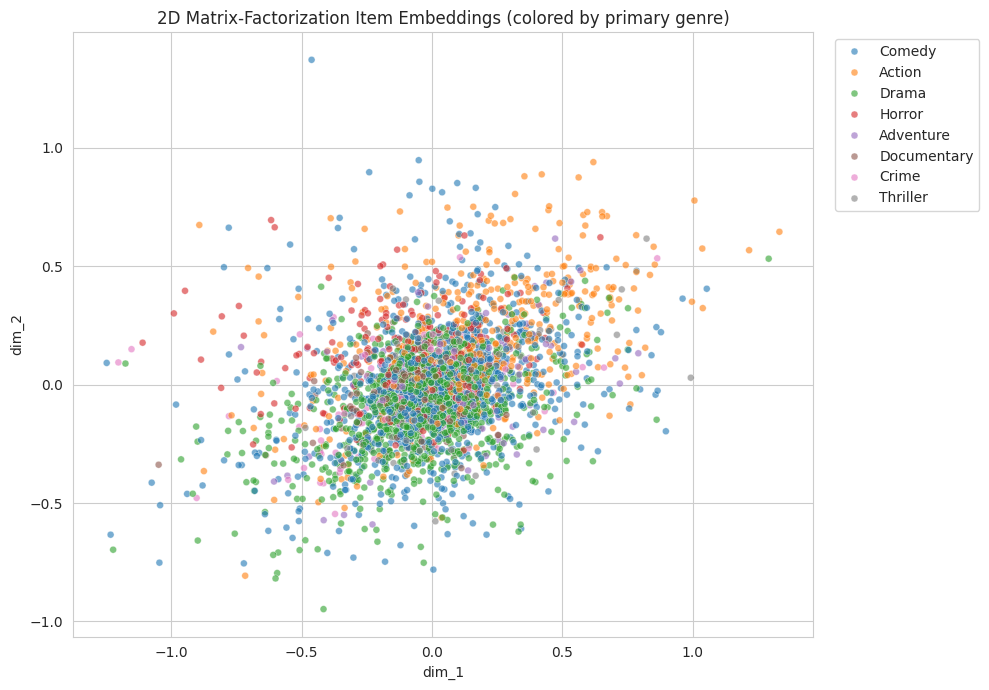

In [ ]:

svd_model_2d = SVD(n_factors=2, n_epochs=20, random_state=42)
svd_model_2d.fit(trainset)

item_factors_2d = svd_model_2d.qi
raw_item_ids_2d = [trainset.to_raw_iid(i) for i in range(item_factors_2d.shape[0])]
emb2d_df = pd.DataFrame(item_factors_2d, columns=['dim_1', 'dim_2'], index=raw_item_ids_2d)
emb2d_df['Title'] = emb2d_df.index.map(movieid_to_title)
emb2d_df['MainGenre'] = emb2d_df.index.map(movies.set_index('MovieID')['Genres'].to_dict()).str.split('|').str[0]

top_genres = emb2d_df['MainGenre'].value_counts().head(8).index
plot_df = emb2d_df[emb2d_df['MainGenre'].isin(top_genres)]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x='dim_1', y='dim_2', hue='MainGenre', palette='tab10', alpha=0.6, s=25)
plt.title('2D Matrix-Factorization Item Embeddings (colored by primary genre)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()


**Analysis of the d=2 embedding plot:**
Movies of the same genre tend to form loose, overlapping clusters rather than perfectly separated
groups : MF embeddings are optimized purely to reconstruct *ratings*, not to encode genre, so genre
similarity only emerges indirectly (movies of the same genre tend to be rated similarly by the
same kinds of users). Compared to a technique like **PCA** on the raw rating vectors (which
maximizes variance explained in the *original* rating space) or **t-SNE/UMAP** (which preserve
local neighborhood structure non-linearly and usually produce tighter, more visually separated
clusters), a 2-dimensional MF embedding is a much coarser summary : 2 latent factors are rarely
enough to capture the many independent "tastes" driving 1M ratings, so at d=2 we mainly see broad
gradients (e.g., mainstream/blockbuster vs. niche) rather than clean genre boundaries. Increasing
d recovers much more structure, at the cost of losing the ability to visualize it directly in 2D.

## 10. User-Based Recommender

We simulate a **new user** rating a handful of movies, then:
1. Find existing users who rated the same movies.
2. Rank them by the count of movies in common with the new user.
3. Take the top 100 "candidate neighbors" and compute Pearson correlation similarity with the
   new user.
4. Take the top 10 most similar users, gather all the movies *they* rated, and compute a
   **weighted rating** = `Rating x Similarity`.
5. Average recommendation score per movie = `sum(weighted ratings) / sum(similarities)`.
6. Recommend the top 10 movies by this score.

In [ ]:

#  Step 0: the new user's ratings
new_user_ratings = {
    'Toy Story (1995)': 5,
    'Liar Liar (1997)': 4,
    'Jurassic Park (1993)': 5,
    'Men in Black (1997)': 4,
    'Independence Day (ID4) (1996)': 3,
}
new_user_df = pd.Series(new_user_ratings, name='new_user')
print(new_user_df)


Toy Story (1995)                 5
Liar Liar (1997)                 4
Jurassic Park (1993)             5
Men in Black (1997)              4
Independence Day (ID4) (1996)    3
Name: new_user, dtype: int64


In [ ]:

rated_titles = list(new_user_ratings.keys())

# Step 1: existing users who rated at least one of the same movies
overlap = df[df['Title'].isin(rated_titles)]

#  Step 2: sort by count of movies in common with the new user
common_counts = overlap.groupby('UserID')['Title'].nunique().sort_values(ascending=False)
top_100_users = common_counts.head(100).index
print(f"Users with overlap: {len(common_counts)}  |  Using top {len(top_100_users)} as candidates")


Users with overlap: 3993  |  Using top 100 as candidates


In [ ]:

#  Step 3: Pearson correlation similarity between the new user and each of the top-100 candidates
candidates_pivot = df[df['UserID'].isin(top_100_users)].pivot_table(
    index='UserID', columns='Title', values='Rating')

def pearson_sim_to_new_user(row, new_user=new_user_df):
    common = row.dropna().index.intersection(new_user.index)
    if len(common) < 2:
        return np.nan
    return np.corrcoef(row[common], new_user[common])[0, 1]

similarity_scores = candidates_pivot.apply(pearson_sim_to_new_user, axis=1).dropna()
similarity_scores = similarity_scores.sort_values(ascending=False)

#  Step 4: top 10 most similar users
top_10_users = similarity_scores.head(10)
print(top_10_users)


UserID
1141    0.979958
1087    0.975900
1425    0.896421
5788    0.891042
1635    0.872872
5627    0.872872
2012    0.872872
36      0.872872
169     0.872872
1613    0.872872
dtype: float64


In [ ]:

# Step 5: gather all movies rated by the top-10 similar users, weight by similarity
top_users_ratings = df[df['UserID'].isin(top_10_users.index)][['UserID', 'Title', 'Rating']].copy()
top_users_ratings['Similarity'] = top_users_ratings['UserID'].map(top_10_users)
top_users_ratings['Weighted_Rating'] = top_users_ratings['Rating'] * top_users_ratings['Similarity']

rec_scores = top_users_ratings.groupby('Title').agg(
    Weighted_Sum=('Weighted_Rating', 'sum'),
    Similarity_Sum=('Similarity', 'sum')
)
rec_scores['Avg_Recommendation_Score'] = rec_scores['Weighted_Sum'] / rec_scores['Similarity_Sum']

#  Step 6: exclude movies the new user has already rated, recommend top 10

final_recs = rec_scores.drop(index=[t for t in rated_titles if t in rec_scores.index], errors='ignore')
final_recs = final_recs.sort_values('Avg_Recommendation_Score', ascending=False).head(10)
final_recs[['Avg_Recommendation_Score']]


,Avg_Recommendation_Score
Title,
Everything You Always Wanted to Know About Sex (1972),5.0
Titus (1999),5.0
Cinema Paradiso (1988),5.0
"Seventh Seal, The (Sjunde inseglet, Det) (1957)",5.0
"Bridge on the River Kwai, The (1957)",5.0
"Fantastic Planet, The (La Planète sauvage) (1973)",5.0
Exotica (1994),5.0
"General, The (1927)",5.0
Funny Bones (1995),5.0


## 11. Questionnaire

**Q1. Users of which age group have watched and rated the most number of movies?**

In [ ]:

top_age_group = df['Age_Group'].value_counts().idxmax()
print("Answer:", top_age_group, "-", df['Age_Group'].value_counts().to_dict())


Answer: 25-34 - {'25-34': 395556, '35-44': 199003, '18-24': 183536, '45-49': 83633, '50-55': 72490, '56+': 38780, 'Under 18': 27211}


**Q2. Users belonging to which profession have watched and rated the most movies?**

In [ ]:

top_occupation = df['Occupation_Desc'].value_counts().idxmax()
print("Answer:", top_occupation)


Answer: college/grad student


**Q3. Most of the users in our dataset who've rated the movies are Male. (T/F)**

In [ ]:

gender_counts = df['Gender'].value_counts()
print(gender_counts)
answer = gender_counts.idxmax() == 'M'
print("Answer:", "True" if answer else "False", "-> Male ratings account for "
      f"{gender_counts['M'] / gender_counts.sum() * 100:.1f}% of all ratings")


Gender
M    753769
F    246440
Name: count, dtype: int64
Answer: True -> Male ratings account for 75.4% of all ratings


**Q4. Most of the movies present in our dataset were released in which decade?**  
(a) 70s (b) 90s (c) 50s (d) 80s

In [ ]:

movies_years = movies['Title'].str.extract(r'\((\d{4})\)$').astype(float)
movies_decade = (movies_years[0] // 10 * 10).astype('Int64').astype(str) + 's'
print(movies_decade.value_counts())
print("\nAnswer: (b) 90s")


0
1990s    2283
1980s     598
1970s     247
1960s     191
1950s     168
2000s     156
1940s     126
1930s      77
1920s      34
1910s       3
Name: count, dtype: int64

Answer: (b) 90s


**Q5. The movie with maximum no. of ratings is ___.**

In [ ]:

top_movie = df['Title'].value_counts().idxmax()
print("Answer:", top_movie, "with", df['Title'].value_counts().max(), "ratings")


Answer: American Beauty (1999) with 3428 ratings


**Q6. Name the top 3 movies similar to 'Liar Liar' on the item-based approach.**

In [ ]:

top3 = recommend_pearson('Liar Liar (1997)').head(3)
print(top3[['Correlation']])
print("\nTop 3 (Pearson, item-based):")
for i, title in enumerate(top3.index, 1):
    print(f"{i}. {title}")


                     Correlation
Title                           
Groove (2000)           0.763630
Picnic (1955)           0.714144
Heavyweights (1994)     0.713459

Top 3 (Pearson, item-based):
1. Groove (2000)
2. Picnic (1955)
3. Heavyweights (1994)


**Q7. On the basis of approach, Collaborative Filtering methods can be classified into ___-based and ___-based.**

**Answer: User-based and Item-based.**
- *User-based CF* finds users similar to the target user and recommends what those similar users liked.
- *Item-based CF* finds items similar to items the target user already liked and recommends those.

**Q8. Pearson Correlation ranges between ___ to ___ whereas, Cosine Similarity belongs to the interval between ___ to ___.**

**Answer:** Pearson Correlation ranges from **-1 to +1**. Cosine Similarity, for ratings data
(all non-negative values), effectively ranges from **0 to +1** (in general, for arbitrary
vectors, cosine similarity ranges from -1 to +1, but rating vectors  being non-negative , never
produce a negative cosine similarity).

**Q9. Mention the RMSE and MAPE that you got while evaluating the Matrix Factorization model.**

In [ ]:

print(f"RMSE (d=4): {rmse:.4f}")
print(f"MAPE (d=4): {mape:.2f}%")


RMSE (d=4): 0.8830
MAPE (d=4): 26.95%


**Q10. Give the sparse 'row' matrix representation for the following dense matrix:**
```
[[1 0]
 [3 7]]
```

In [ ]:

dense = np.array([[1, 0],
                   [3, 7]])
sparse_row = csr_matrix(dense)

print("Dense matrix:\n", dense)
print("\nCSR (Compressed Sparse Row) representation:")
print(sparse_row)
print("\ndata    (non-zero values, row-major order):", sparse_row.data)
print("indices (column index of each value)      :", sparse_row.indices)
print("indptr  (cumulative non-zero count per row):", sparse_row.indptr)


Dense matrix:
 [[1 0]
 [3 7]]

CSR (Compressed Sparse Row) representation:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (2, 2)>
  Coords	Values
  (0, 0)	1
  (1, 0)	3
  (1, 1)	7

data    (non-zero values, row-major order): [1 3 7]
indices (column index of each value)      : [0 0 1]
indptr  (cumulative non-zero count per row): [0 1 3]


**Explanation:** CSR stores three arrays:
- `data = [1, 3, 7]` : the non-zero values, read row by row.
- `indices = [0, 0, 1]` : the column index of each value in `data`.
- `indptr = [0, 1, 3]` : for each row, the index into `data`/`indices` where that row's values
  start; row *i*'s values are `data[indptr[i] : indptr[i+1]]`. Here, row 0 has 1 value (`data[0:1]
  = [1]`, column 0) and row 1 has 2 values (`data[1:3] = [3, 7]`, columns `[0, 1]`).

In [ ]:
!jupyter nbconvert --to html Zee_Recommender_System_BusinessCase.ipynb

[NbConvertApp] Converting notebook Zee_Recommender_System_BusinessCase.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 1088371 bytes to Zee_Recommender_System_BusinessCase.html
